# Imports

In [12]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc

from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from models.trainer_ESN_LBFGS import fit_ESN_MMD_LBFGS

from loss.loss import compute_mmd_loss

from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv
from utils.analyse_controlled_experiments import *
from utils.analyse_results import *
from utils.data import *

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generators

Initialize ESN and target ESN parameters.

In [13]:
T = 100 # length of time series
N = 50  # number of samples (for target)
N_esn = 50
target_rho = 0.7
xi_ma_theta = None 
d = 1   # dimension of time series
W_init_std = 0.1 # standard deviation for initializing the ESN output weight matrix W

target_type = "returns" # choice of target type: "returns", "log_returns", "sqrd_log_returns", "log_sqrd_returns"


In [14]:
# Shared by both ESN
h, m, d = 500, 20, 1 # ESN hyperparameters: reservoir size, input dimension (\xi : randomness), output dimension
activation = "tanh" 
quad_feedback = False # whether to include quadratic feedback in the ESN reservoir (to capture some nonlinearity and volatility clustering)
quad_gain = 0.0 # if set to 0.0 then no quadratic feedback
xi_scale = 1.0
eta_scale = 0.05
C_scale = 0.5

washout_len = h

A = torch.randn(h, h) / (h ** 0.5) # ESN reservoir weight matrix
C = C_scale * torch.randn(h, m) / (m ** 0.5) # ESN input weight matrix

Create trainable ESN and target ESN instances.

In [15]:
omega = 0.01 # GARCH omega parameter
alpha = [0.1] # GARCH alpha parameter
beta = [0.85] # GARCH beta parameter
sigma2_0 = 0.2 # = omega/(1-alpha-beta) to ensure stationarity and a certain level of volatility
burnin = 50

target_generator = GARCH11(T=T, omega=omega, alpha=alpha[0], beta=beta[0], d=d, sigma2_0=sigma2_0, burnin=burnin)

In [16]:
# ESN estimator
esn = ESNGenerator(A, C, out_dim=d, xi_scale=xi_scale, 
                   eta_scale=eta_scale, activation=activation, 
                   target_rho=target_rho, xi_ma_theta=xi_ma_theta, 
                   quad_feedback=quad_feedback, quad_gain=quad_gain,
                   W_init=None, washout_len=washout_len) # if random W
                #  W_init=W_fixed) # if want to start from correct W

# Kernels

In [17]:
with torch.no_grad():
    Z_target_raw = target_generator.generate(T=T, N=N).to(device=device, dtype=dtype)
    Z_esn_raw = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

# Apply the selected target transformation
eps = 1e-8

if target_type == "returns":
    Z_target = Z_target_raw
    Z_esn = Z_esn_raw
elif target_type == "log_returns":
    Z_target = torch.log1p(Z_target_raw) # this doesnt make sense with real returns (I need percentage returns)
    Z_esn = torch.log1p(Z_esn_raw)
elif target_type == "sqrd_log_returns": # this doesnt make sense with real returns (I need percentage returns)
    log_r = torch.log1p(Z_target_raw)
    Z_target = log_r ** 2
    Z_esn = torch.log1p(Z_esn_raw) ** 2
elif target_type == "log_sqrd_returns":
    Z_target = torch.log(Z_target_raw ** 2 + eps)
    Z_esn = torch.log(Z_esn_raw ** 2 + eps)

print(f"Generated data shapes: Z_target: {Z_target.shape}, Z_esn: {Z_esn.shape}")
_median_heuristic_sigma = median_heuristic_sigma(Z_target, Z_esn)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Generated data shapes: Z_target: torch.Size([50, 100, 1]), Z_esn: torch.Size([50, 100, 1])
Median heuristic sigma: 11.505086


In [18]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**{'static_kernel_type': static_kernel_type, 'n_levels': n_levels, 'kernel_sigma': disc_sig_kernel_sigma})

#---------------------------------
# Define the pde signature kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# # Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

## Choose kernel

Choose one kernel

In [19]:
# kernel = sig_disc_kernel      # discretized signature kernel
kernel = sig_pde_kernel        # pde signature kernel
# kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel      # volterra kernel

Run initial MMD to check and as a baseline

In [20]:
if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")

# initial mmd:
initial_mmd = compute_mmd_loss(kernel, Z_target, Z_esn) if kernel_mode == "sequential" else compute_mmd_loss(kernel, Z_target.reshape(Z_target.shape[0], -1), Z_esn.reshape(Z_esn.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

Using kernel: SigKernel with kernel mode: sequential
Initial MMD with SigKernel kernel: 1.054992


# Baseline MMD

In [21]:
# iterations = 1000
# N_small = N
# N_large = N_esn
# baseline_mmd = compute_baseline_mmd(target_generator,kernel,noise,iterations,N_small,N_large,kernel_mode,dtype,device, target_type)
# print("Baseline MMD:", baseline_mmd)

# Statistical Analysis Before Fitting

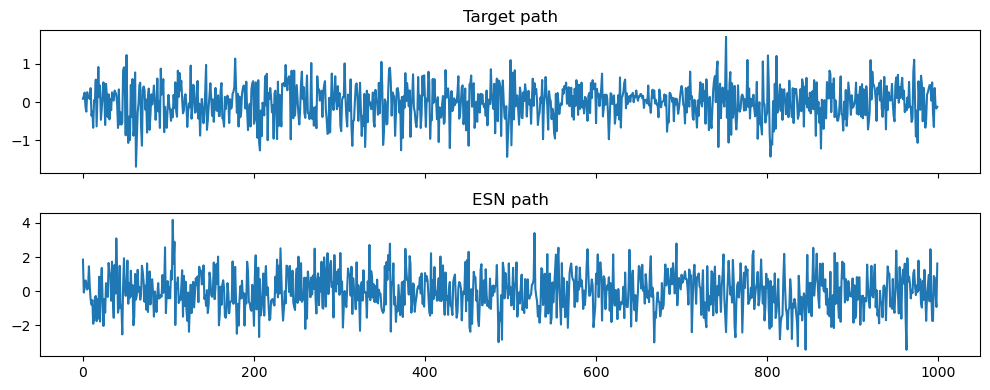

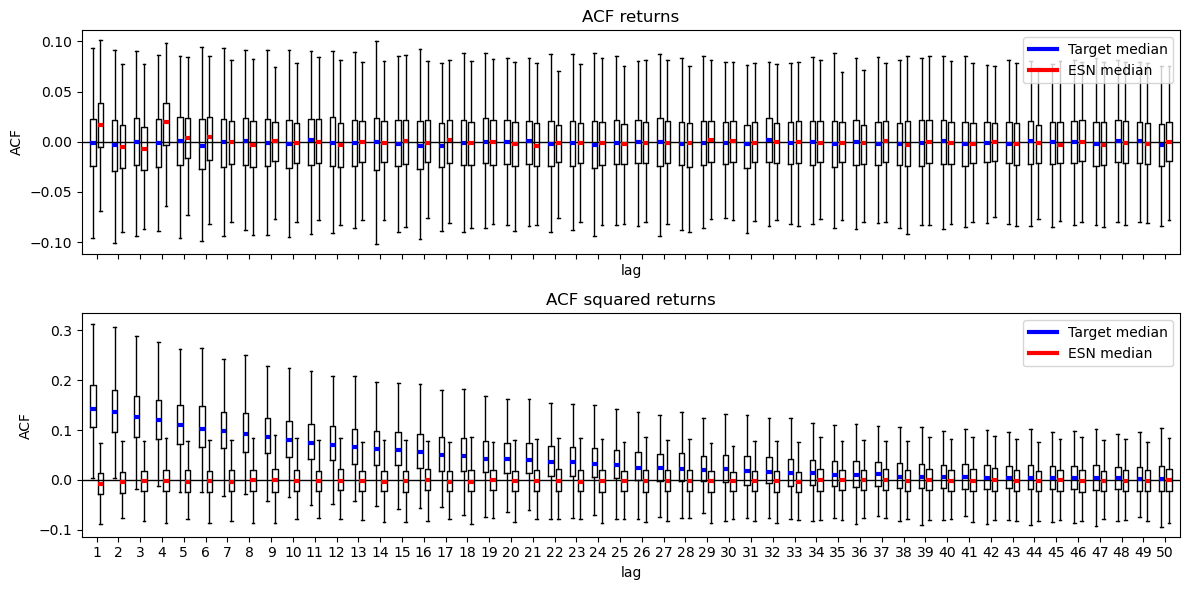

In [22]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [23]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")



ACF two-sample test summary
ACF(joint) -> T_obs: 5.814914, p_value: 0.003000
ACF(x^2)   -> T_obs: 3.977919, p_value: 0.000000
ACF(x)     -> T_obs: 1.836995, p_value: 0.654000


# Fit ESN

In [24]:
print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
results = fit_ESN_MMD_LBFGS(esn = esn, 
                            Z_target = Z_target,
                            kernel = kernel, 
                            kernel_mode = kernel_mode,
                            N_model= N_esn, 
                            lead_lag=False,
                            lags=0,
                            max_iter = 200, 
                            lr=0.1, 
                            force_float64=True,
                            verbose=True,
                            target_type=target_type
)


Using kernel: SigKernel with kernel mode: sequential
MMD initial: 0.8782394682993928
Eval 100: Loss 0.016978
Eval 200: Loss -0.000343
Eval 300: Loss -0.000343
Eval 400: Loss -0.000343
Eval 500: Loss -0.000343
Eval 600: Loss -0.000343
Eval 700: Loss -0.000343
Eval 800: Loss -0.000343
Eval 900: Loss -0.000343
Eval 1000: Loss -0.000343
Eval 1100: Loss -0.000343
Eval 1200: Loss -0.000276
Eval 1300: Loss -0.000343
Eval 1400: Loss -0.000343
Eval 1500: Loss -0.000343
Eval 1600: Loss -0.000343
Eval 1700: Loss -0.000343
Eval 1800: Loss -0.000343
Eval 1900: Loss -0.000343
Eval 2000: Loss -0.000343
Eval 2100: Loss -0.000343
Eval 2200: Loss -0.000343
Eval 2300: Loss -0.000343
Eval 2400: Loss -0.000343
Eval 2500: Loss -0.000271
MMD final: -0.0003429180744228765


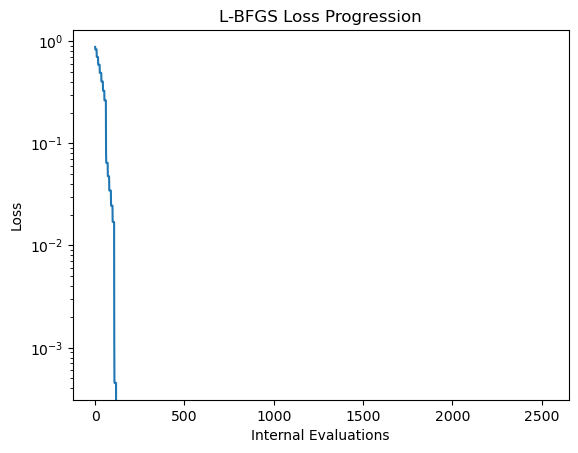

In [25]:
loss_history = results['loss_history']
plt.plot(loss_history)
plt.xlabel('Internal Evaluations')
plt.ylabel('Loss')
plt.title('L-BFGS Loss Progression')
plt.yscale('log') # Useful if loss drops several orders of magnitude
plt.show()

# Statistical Analysis After Fitting

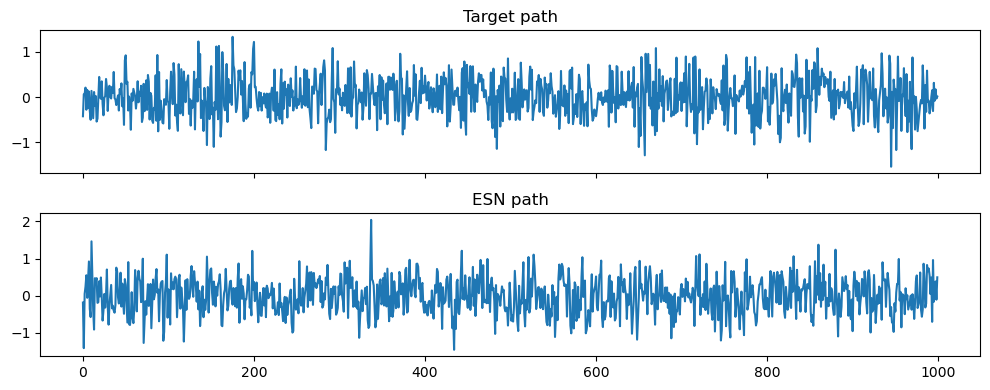

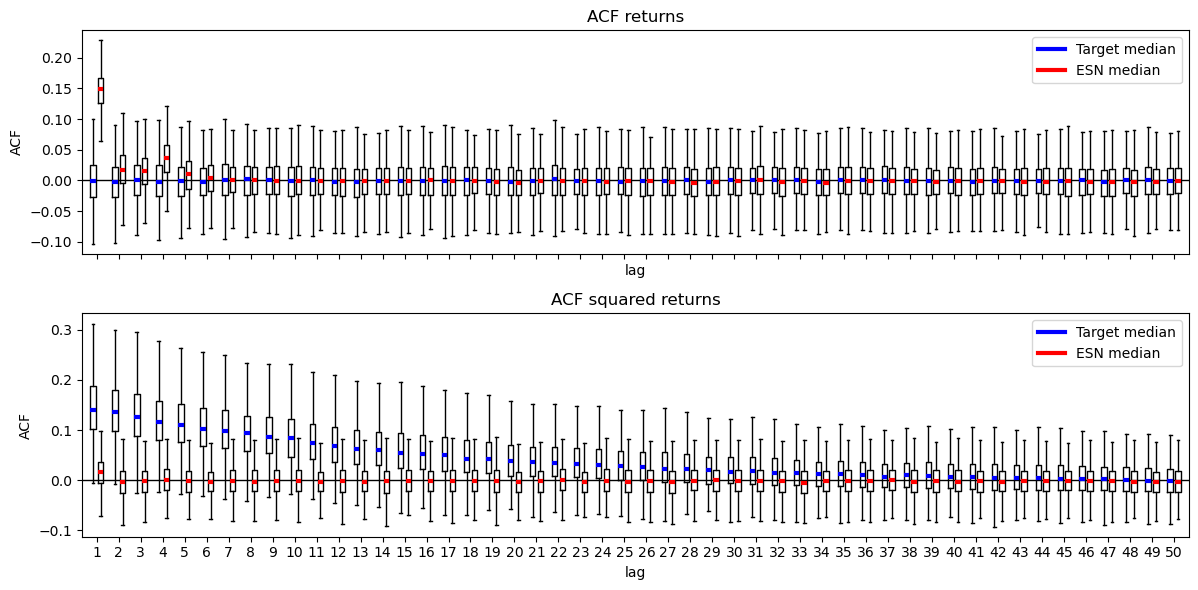

In [32]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [31]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")



ACF two-sample test summary
ACF(x)     -> T_obs: 3.963328, p_value: 0.000000
ACF(x^2)   -> T_obs: 4.262294, p_value: 0.000000
ACF(joint) -> T_obs: 8.225622, p_value: 0.000000


# Check states with the current activation to see saturation levels

In [28]:
Z, X, pre_activation = esn.forward(T=200, return_states=True, track_saturation=True)
print("activation type:", activation)

activation type: tanh


In [29]:
# pre: (N, T, h)
pre_act = pre_activation.detach()

# boolean mask
mask_1 = (pre_act.abs() > 1.0).float()
mask_2 = (pre_act.abs() > 2.0).float()

# percentage per dimension (average over N and T)
perc_per_dim_1 = mask_1.mean(dim=(0, 1))   # shape (h,)

# percentage |z|>2 per dimension
perc_per_dim_2 = mask_2.mean(dim=(0, 1))   # shape (h,)

# mean over dimensions
mean_perc_1 = perc_per_dim_1.mean().item()
mean_perc_2 = perc_per_dim_2.mean().item()

print("mean percentage |z|>1 across dims:", mean_perc_1)
print("mean percentage |z|>2 across dims:", mean_perc_2)
print("percentage |z|>1 per dim (first 3 dim):", perc_per_dim_1[:3].cpu().numpy())
print("percentage |z|>2 per dim (first 3 dim):", perc_per_dim_2[:3].cpu().numpy())

mean percentage |z|>1 across dims: 0.09464999288320541
mean percentage |z|>2 across dims: 0.0013599998783320189
percentage |z|>1 per dim (first 3 dim): [0.11  0.07  0.085]
percentage |z|>2 per dim (first 3 dim): [0. 0. 0.]


In [30]:
import plotly.graph_objects as go

pa = pre_activation.detach().cpu()

if pa.dim() == 3:
    pa = pa[0]   # (T, h)

T, h = pa.shape

fig = go.Figure()

for i in range(h):
    fig.add_trace(
        go.Scatter(
            y=pa[:, i],
            mode="markers",   # <-- key change
            name=f"dim {i}",
            visible=(i == 0),
            marker=dict(size=4)  # optional, makes points clearer
        )
    )

buttons = []
for i in range(h):
    visible = [False] * h
    visible[i] = True
    buttons.append(dict(
        label=f"dim {i}",
        method="update",
        args=[{"visible": visible},
              {"title": f"Pre-activation dim {i}"}]
    ))

fig.update_layout(
    updatemenus=[dict(buttons=buttons)],
    title="Pre-activation (dim 0)",
    xaxis_title="t",
    yaxis_title="z"
)

fig.show()